 ## 1. Introduction

### Project Context

HealthConnect Clinic maintains appointment records containing patient, appointment, reminder, and attendance information. This analysis aims to understand appointment attendance and no-show patterns and identify factors associated with missed appointments.

The analysis focuses on appointment characteristics, patient history, reminder activity, waiting time, distance to the clinic, and appointment outcomes. Findings will support KPI development and evidence-based recommendations for improving appointment management and attendance.

### Business Questions

The initial analysis will be guided by the following business questions:

1. How does appointment attendance vary across reminder channels and appointments where no reminder was sent?
2. How is previous no-show behaviour associated with current appointment outcomes?
3. Which days of the week and time periods have the highest appointment volumes?
4. How is waiting time associated with appointment outcomes?
5. What proportion of appointments did not receive a reminder?
6. Does appointment type influence appointment outcomes?

## 2. Environment Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
DATA_PATH = "data/HealthConnect_Appointment_Data.csv"

df = pd.read_csv(DATA_PATH)

## 3. Data Preparation and Quality Assessment

### Dataset Overview

In [3]:
df.head()

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


#### Dataset Scope
The appointment dataset contains information relating to:

- Patient demographics
- Appointment details
- Booking information
- Previous appointment history
- Previous no-shows
- Reminder information
- Distance to the clinic
- Waiting time
- Appointment outcomes


#### Dataset Structure

In [4]:
# rows and columns
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 5000
Columns: 18


### Data Types

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   appointment_id         5000 non-null   object 
 1   patient_id             5000 non-null   object 
 2   gender                 5000 non-null   object 
 3   age                    5000 non-null   int64  
 4   age_group              5000 non-null   object 
 5   appointment_type       5000 non-null   object 
 6   booking_date           5000 non-null   object 
 7   appointment_date       5000 non-null   object 
 8   appointment_day        5000 non-null   object 
 9   appointment_time       5000 non-null   object 
 10  booking_lead_days      5000 non-null   int64  
 11  previous_appointments  5000 non-null   int64  
 12  previous_no_shows      5000 non-null   int64  
 13  reminder_sent          5000 non-null   object 
 14  reminder_channel       3634 non-null   object 
 15  dist

### Missing Values

In [6]:
df.isna().sum()

appointment_id              0
patient_id                  0
gender                      0
age                         0
age_group                   0
appointment_type            0
booking_date                0
appointment_date            0
appointment_day             0
appointment_time            0
booking_lead_days           0
previous_appointments       0
previous_no_shows           0
reminder_sent               0
reminder_channel         1366
distance_to_clinic_km      90
waiting_time_minutes       60
appointment_outcome         0
dtype: int64

#### Distance to clinic and Waiting time in minutes distribution by appointment outcome

In [7]:
df[df["reminder_channel"]== "None"]

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome


In [8]:
df["distance_missing"] = df["distance_to_clinic_km"].isna()
df["waiting_missing"] = df["waiting_time_minutes"].isna()

df.groupby("distance_missing")["appointment_outcome"].value_counts(normalize=True)

distance_missing  appointment_outcome
False             No-Show                0.483910
                  Attended               0.463340
                  Cancelled              0.052749
True              No-Show                0.522222
                  Attended               0.433333
                  Cancelled              0.044444
Name: proportion, dtype: float64

In [12]:
df.groupby("waiting_missing")["appointment_outcome"].value_counts(normalize=True)

waiting_missing  appointment_outcome
False            No-Show                0.482996
                 Attended               0.464170
                 Cancelled              0.052834
True             No-Show                0.616667
                 Attended               0.350000
                 Cancelled              0.033333
Name: proportion, dtype: float64

### Duplicate Records

In [9]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate appointment IDs:", df["appointment_id"].duplicated().sum())

Duplicate rows: 0
Duplicate appointment IDs: 0


### Categorical Consistency

In [10]:
categorical_cols = [
    "gender",
    "age_group",
    "appointment_type",
    "appointment_day",
    "appointment_time",
    "reminder_sent",
    "reminder_channel",
    "appointment_outcome"
]

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))


gender
gender
Female               2488
Male                 2404
Prefer not to say     108
Name: count, dtype: int64

age_group
age_group
65+      1241
35-44     819
55-64     800
45-54     793
25-34     783
18-24     564
Name: count, dtype: int64

appointment_type
appointment_type
General Consultation       2086
Follow-up                  1421
Specialist Consultation     900
Diagnostic Test             593
Name: count, dtype: int64

appointment_day
appointment_day
Wednesday    737
Sunday       737
Friday       728
Saturday     724
Monday       701
Tuesday      689
Thursday     684
Name: count, dtype: int64

appointment_time
appointment_time
Morning      2227
Afternoon    2094
Evening       679
Name: count, dtype: int64

reminder_sent
reminder_sent
Yes    3634
No     1366
Name: count, dtype: int64

reminder_channel
reminder_channel
SMS         2000
NaN         1366
WhatsApp    1101
Email        533
Name: count, dtype: int64

appointment_outcome
appointment_outcome
No-Show      2423
A

### Check previous no-shows does not exceed previous appointments

In [ ]:

df[df["previous_no_shows"] > df["previous_appointments"]]

### Reminder Channel Validity

In [7]:
pd.crosstab(
    df["reminder_sent"],
    df["reminder_channel"],
    dropna=False
)

reminder_channel,Email,SMS,WhatsApp,NaN
reminder_sent,,,,
No,0,0,0,1366
Yes,533,2000,1101,0


#### Recode nan reminder channel to "No reminder"

In [20]:
df["reminder_channel"] = df["reminder_channel"].fillna("No reminder")

# confirmation
df["reminder_channel"].value_counts(dropna=False)

reminder_channel
SMS            2000
No reminder    1366
WhatsApp       1101
Email           533
Name: count, dtype: int64

### Date Validity

In [9]:
# formatted date fields to correct data type
df["booking_date"] = pd.to_datetime(df["booking_date"])
df["appointment_date"] = pd.to_datetime(df["appointment_date"])

(df["appointment_date"] < df["booking_date"]).sum()

(df["previous_no_shows"] < 0).sum()
(df["previous_appointments"] < 0).sum()
(df["booking_lead_days"] < 0).sum()
(df["waiting_time_minutes"] < 0).sum()
(df["distance_to_clinic_km"] < 0).sum()

np.int64(0)

### Data Quality Observation
- `reminder_channel` contains `SMS`, `WhatsApp`, and `Email`, with `None` values representing appointments where no reminder was sent; these were recoded as `No reminder` for analysis.
- `distance_to_clinic_km` has 90 missing values (1.8%), while `waiting_time_minutes` has 60 (1.2%). The data dictionary identifies these as limited missing values.
- Missing waiting-time records show a higher No-Show proportion (61.7%) than records with available waiting-time data (48.3%); this will be considered when interpreting related findings.
- Booking and appointment dates were converted from object to datetime for time-based analysis.
- Categorical values were consistent, and no duplicate records were identified.

## 4. Exploratory Data Analysis

### 4.1 Appointment Outcomes

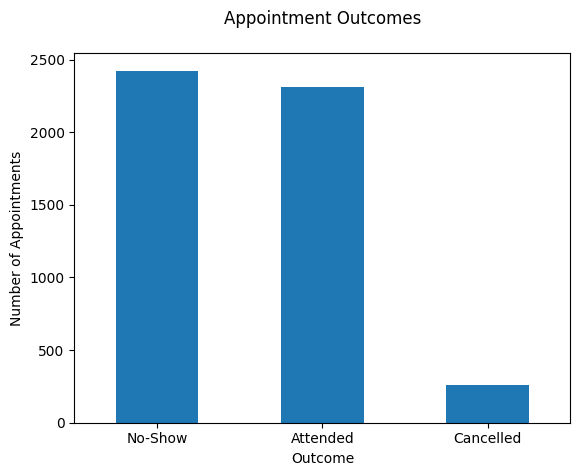

In [10]:
outcomes = df["appointment_outcome"].value_counts()
outcomes.plot(kind="bar")

plt.title("Appointment Outcomes\n")
plt.xlabel("Outcome")
plt.ylabel("Number of Appointments")
plt.xticks(rotation=0)
plt.show()

> **Observation**: No-show appointments are the most common outcome, accounting for approximately **48%** of appointments, slightly above attend appointments at **46%**. Cancellations represent a much smaller share, at around **5%**

### 4.2 Reminder and Appointment History

#### - Reminder Channels

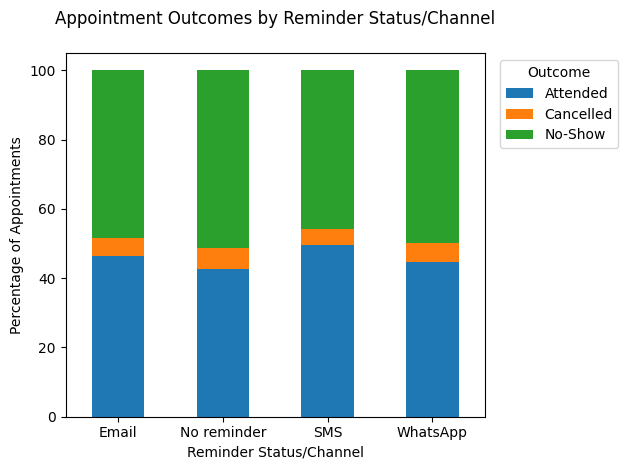

In [21]:
reminder_outcome = pd.crosstab(
    df["reminder_channel"],
    df["appointment_outcome"],
    normalize="index"
) * 100

reminder_outcome.plot(
    kind="bar",
    stacked=True
)

plt.title("Appointment Outcomes by Reminder Status/Channel\n")
plt.xlabel("Reminder Status/Channel")
plt.ylabel("Percentage of Appointments")
plt.xticks(rotation=0)

plt.legend(
    title="Outcome",
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

plt.tight_layout()
plt.show()

> **Observation**: SMS recorded the highest attendance proportion at approximately **50%**, followed by Email (**~47%**), WhatsApp (**~45%**), and appointments with no reminder (**~43%**). Although SMS shows the highest attendance rate, the differences across reminder statuses/channels are relatively small, suggesting that no single reminder channel has a substantially stronger association with attendance in this dataset.

#### - Previous No-Shows

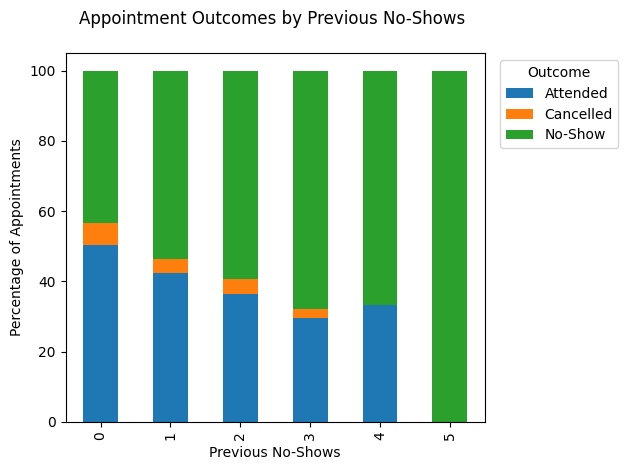

In [16]:
previous_outcome = pd.crosstab(
    df["previous_no_shows"],
    df["appointment_outcome"],
    normalize="index"
) * 100

previous_outcome.plot(
    kind="bar",
    stacked=True
)

plt.title("Appointment Outcomes by Previous No-Shows \n")
plt.xlabel("Previous No-Shows")
plt.ylabel("Percentage of Appointments")
plt.legend(
    title="Outcome",
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)
plt.tight_layout()
plt.show()

> **Observation**: Current no-show rates generally increase as previous no-shows increase. Patients with multiple previous no-shows therefore appear more likely to miss subsequent appointments, suggesting that previous attendance behaviour may be a useful indicator of future no-show risk.

### 4.3 Appointment Characteristics

#### - Day and Time

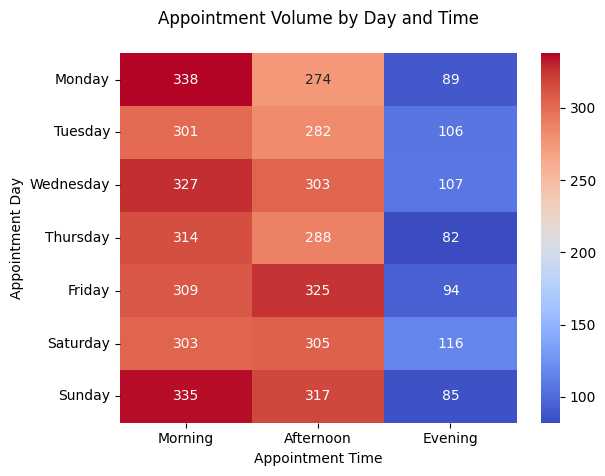

In [18]:
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

time_order = [
    "Morning", "Afternoon", "Evening"
]

day_time = pd.crosstab(
    df["appointment_day"],
    df["appointment_time"]
).reindex(
    index=day_order,
    columns=time_order
)

sns.heatmap(day_time, annot=True, fmt="d", cmap="coolwarm")

plt.title("Appointment Volume by Day and Time\n")
plt.xlabel("Appointment Time")
plt.ylabel("Appointment Day")

plt.show()


> **Observation**: Appointment volumes are concentrated in the **morning** and **afternoon**, while evening appointments consistently record substantially lower volumes. Daily volumes are relatively similar, although Monday morning has the highest individual day-time volume.

#### - Appointment Type

In [74]:
appointment_type_distribution = (
    df["appointment_type"]
    .value_counts()
    .rename("Appointments")
    .to_frame()
)

appointment_type_distribution["Percentage"] = (
    appointment_type_distribution["Appointments"]
    / len(df) * 100
).round(2)

appointment_type_distribution

,Appointments,Percentage
appointment_type,,
General Consultation,2086,41.72
Follow-up,1421,28.42
Specialist Consultation,900,18.00
Diagnostic Test,593,11.86


> **Observation**: General consultations account for the largest share of appointments, with **2,086** appointments (**41.72%**), followed by Follow-up appointments at **28.42%**. Specialist consultations and Diagnostic Tests account for **18.00% **and **11.86%**, respectively.

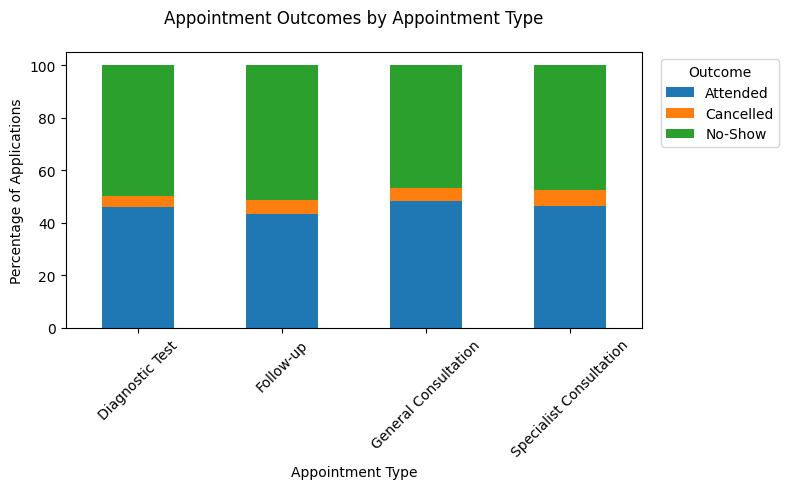

In [19]:
appointment_types_outcomes = pd.crosstab(
    df["appointment_type"],
    df["appointment_outcome"],
    normalize="index"
) * 100

appointment_types_outcomes.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)


plt.title("Appointment Outcomes by Appointment Type\n")
plt.xlabel("Appointment Type")
plt.ylabel("Percentage of Applications")
plt.xticks(rotation=45)
plt.legend(
    title="Outcome",
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)
plt.tight_layout()
plt.show()

> **Observation**: Appointment outcome distributions are relatively similar across appointment types, although Follow-up and Specialist Consultation show slightly higher cancellation proportions. The relatively small differences suggest that appointment type may not be a major differentiator of appointment outcomes.

### - Waiting Time

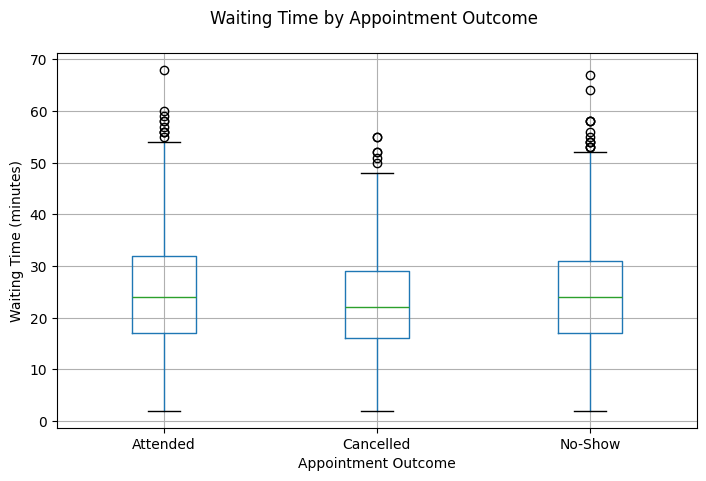

In [73]:
df.boxplot(
    column="waiting_time_minutes",
    by="appointment_outcome",
    figsize=(8, 5)
)

plt.title("Waiting Time by Appointment Outcome \n")
plt.suptitle("")
plt.xlabel("Appointment Outcome")
plt.ylabel("Waiting Time (minutes)")
plt.show()

> **Observation**: Median waiting times are relatively similar across appointment outcomes, at approximately **22–24 minutes**, with substantial overlap in the distributions. This suggests that waiting time does not appear to be a strong differentiator of appointment outcomes based on the initial analysis.

### Patient and Accessibility Characteristics

#### - Age Group

In [22]:
pd.crosstab(
    df["age_group"],
    df["appointment_outcome"],
    normalize="index"
).mul(100).round(2)

appointment_outcome,Attended,Cancelled,No-Show
age_group,,,
18-24,45.57,4.26,50.18
25-34,45.08,4.21,50.70
35-44,45.67,5.98,48.35
45-54,46.03,5.93,48.05
55-64,45.00,4.25,50.75
65+,48.75,6.12,45.12


> **Observation**: Appointment outcomes are relatively consistent across age groups, with no-show rates ranging from approximately **45%** to **51%**. The limited variation suggests that age group may not be a strong differentiator of appointment attendance in this dataset.

#### - Distance to clinic

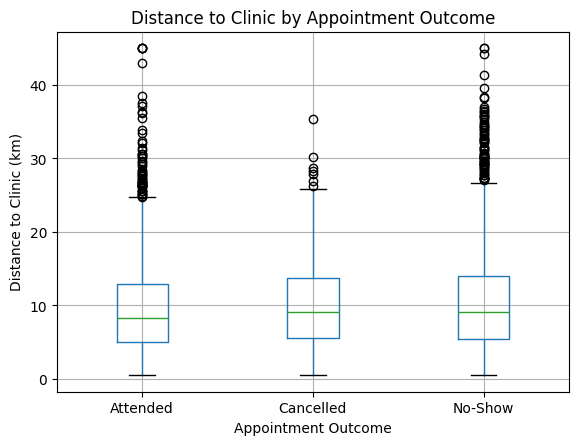

In [23]:
df.boxplot(
    column="distance_to_clinic_km",
    by="appointment_outcome"
)

plt.title("Distance to Clinic by Appointment Outcome")
plt.suptitle("")
plt.xlabel("Appointment Outcome")
plt.ylabel("Distance to Clinic (km)")

plt.show()

> **Observation**: Median distance to the clinic is higher for No-Show and Cancelled appointments (**approximately 9 km**) than for Attended appointments (**approximately 8 km**). However, the distributions overlap considerably, suggesting that distance to the clinic alone may not strongly differentiate appointment outcomes.

## 5. KPIs

#### No-Show Rate

**Definition:**
The proportion of appointments that resulted in a No-Show.

**Linked Business Question:**
How is previous no-show behaviour associated with current appointment outcomes?

**Calculation:**

In [75]:
no_show_rate = (
    (df["appointment_outcome"] == "No-Show").mean() * 100
)

round(no_show_rate, 2)

np.float64(48.46)

> **Interpretation:** Approximately **48%** of appointments resulted in a no-show, indicating that missed
appointments represent a significant attendance challenge for HealthConnect.

#### Reminder Efffectiveness Rate

**Definition:**  
The proportion of appointments for which no reminder was sent.

**Linked Business Question:**  
What proportion of appointments did not receive a reminder?

**Calculation:**

In [79]:
reminder_effectiveness = (
    df[df["reminder_sent"] == "Yes"]
    .groupby("reminder_channel")["appointment_outcome"]
    .apply(lambda x: (x == "Attended").mean() * 100)
    .round(2)
)

reminder_effectiveness

reminder_channel
Email       46.53
SMS         49.60
WhatsApp    44.60
Name: appointment_outcome, dtype: float64

> **Interpretation:** SMS recorded the highest attendance rate, although the difference between
reminder channels and the no-reminder group was relatively small.

#### Reminder Non-send Rate

**Definition:**  
The proportion of appointments for which no reminder was sent.

**Linked Business Question:**  
What proportion of appointments did not receive a reminder?

**Calculation:**

In [80]:
reminder_non_send_rate = (
    (df["reminder_sent"] == "No").mean() * 100
)

round(reminder_non_send_rate, 2)

np.float64(27.32)

> **Interpretation:**  Approximately **27%** of appointments did not receive a reminder, indicating the
extent of appointments currently outside the reminder process.

#### Average Waiting Time

**Definition:**  
The mean estimated waiting time across appointments with available waiting
time data.

**Linked Business Question:**  
How is waiting time associated with appointment outcomes?

**Calculation:**

In [81]:
average_waiting_time = df["waiting_time_minutes"].mean()

round(average_waiting_time, 2)

np.float64(24.19)

> **Interpretation:**  The average estimated waiting time was approximately **24 minutes**. This provides
a baseline for assessing whether waiting time is associated with appointment
outcomes.

## 6. Key Insights

### 1. No-shows represent a significant attendance challenge

No-shows are the most common appointment outcome, accounting for approximately
**47.5% of all appointments**, slightly exceeding attended appointments at
approximately **46.2%**. This indicates that missed appointments represent a
significant operational challenge for HealthConnect.

### 2. Previous no-show behaviour is strongly associated with future no-shows

Current no-show rates increase substantially with patients' previous no-show
history, rising from **43.51% among patients with no previous no-shows** to
**67.95% among those with three previous no-shows**. Patients with repeated
previous no-shows therefore represent a potentially higher-risk group for
future missed appointments.

### 3. Reminder channels show only modest differences in attendance

SMS recorded the highest attendance proportion at approximately **50%**,
followed by Email (~47%), WhatsApp (~45%), and appointments where no reminder
was sent (~43%). Although reminded appointments generally show slightly higher
attendance, the relatively small differences between channels suggest that no
single reminder channel has a substantially stronger association with
attendance in this dataset.

### 4. A substantial proportion of appointments receive no reminder

Approximately **27% of appointments did not receive a reminder**. This
represents a notable share of appointment volume and provides an opportunity
to examine whether broader reminder coverage could support attendance.

### 5. Appointment demand is concentrated in morning and afternoon periods

Morning and afternoon appointments account for substantially higher volumes
than evening appointments. In contrast, appointment volumes are relatively
consistent across the days of the week. This suggests that appointment demand
is more strongly differentiated by **time of day than by day of week**.

### 6. Waiting time, distance, age and appointment type show limited differentiation

Waiting times are relatively similar across outcomes, with median waiting
times of approximately **22–24 minutes** and substantial overlap between
groups. Similarly, distance to the clinic and age group show limited
differences in appointment outcomes. Outcome distributions are also broadly
similar across appointment types. These variables therefore appear to be
weaker differentiators of attendance than previous no-show behaviour.

## 7. Business Recommendations

### 1. Strengthen reminder coverage using a multi-channel approach

Approximately 27% of appointments did not receive a reminder, while SMS recorded
the highest attendance proportion among the observed reminder groups. Although
the differences between channels were relatively small, HealthConnect should
consider a multi-channel reminder strategy, with SMS used alongside Email or
WhatsApp where appropriate.

Rather than assuming that one channel is universally more effective, the
organisation could pilot combinations such as SMS + Email or SMS + WhatsApp
and monitor attendance and no-show rates to determine the most effective
approach.

### 2. Prioritise patients with previous no-show history

No-show rates increased substantially as previous no-show history increased,
indicating that patients with repeated missed appointments may represent a
higher-risk group.

HealthConnect could introduce targeted follow-up for patients with previous
no-shows, such as additional reminders, confirmation requests, or appointment
reconfirmation before the scheduled date.

### 3. Investigate the underlying reasons for repeated no-shows

Targeted surveys or feedback forms could be sent to patients with previous
no-show history to understand the barriers contributing to missed
appointments.

Potential factors such as scheduling difficulties, communication issues,
transportation challenges, or patient experience should be investigated
rather than assumed. Feedback from these patients could then be used to design
more appropriate interventions.

### 4. Improve appointment capacity and waiting-time management

Although waiting time showed relatively similar distributions across
appointment outcomes, reducing unnecessary waiting remains relevant to the
overall patient experience.

HealthConnect should review appointment scheduling, staff allocation, and
facility capacity to identify bottlenecks that may contribute to longer
waiting periods and improve the efficiency of appointment handling.

### 5. Use appointment demand patterns to support resource planning

Appointment volumes are concentrated in the morning and afternoon, while
evening appointments consistently record substantially lower volumes.

Staffing and resource allocation could therefore be aligned with periods of
higher appointment demand to improve service capacity and minimise potential
operational bottlenecks.

### 6. Monitor appointment outcomes by patient and appointment characteristics

HealthConnect should continue monitoring no-show, attendance, and cancellation
rates across previous no-show history, reminder status, appointment type, and
other relevant characteristics.

This would allow the organisation to identify emerging high-risk patterns and
evaluate whether interventions introduced to reduce no-shows are actually
improving attendance.

### 7. Evaluate interventions using attendance metrics

Any changes to reminder coverage, follow-up procedures, or scheduling practices
should be monitored using no-show and attendance rates. HealthConnect could
compare outcomes before and after implementation to determine whether the
interventions are associated with measurable improvements.

## 8. Limitations

- **Missing data:** `distance_to_clinic_km` and `waiting_time_minutes` contain a
  small number of missing observations. These records were retained rather
  than imputed to avoid introducing assumptions into the analysis.

- **Synthetic dataset:** The dataset is synthetic and anonymised. Therefore,
  observed patterns may not fully represent real-world patient behaviour or
  operational conditions at HealthConnect.

- **Observational analysis:** The analysis identifies patterns and
  associations between variables but does not establish causal relationships.
  For example, differences in attendance across reminder channels do not
  demonstrate that a particular channel causes higher attendance.

- **Limited patient context:** The dataset does not capture potentially
  relevant factors such as reasons for missed appointments, patient
  satisfaction, staff experience, health status, or socioeconomic
  circumstances. These factors may help explain observed no-show behaviour.

- **Reminder information:** `reminder_channel` indicates the recorded
  delivery channel but does not provide information on whether patients
  actually received, opened, or engaged with the reminder.

- **Waiting-time interpretation:** Waiting time is estimated and contains
  missing values. Its relationship with appointment outcomes should therefore
  be interpreted with caution.

- **Limited evidence for distance-related interventions:** Distance to the
  clinic shows only modest differences across appointment outcomes. The
  current analysis therefore does not provide sufficient evidence to conclude
  that distance is a major driver of no-shows.

## 9. Conclusion

This analysis provides an initial view of appointment attendance and potential no-show patterns at HealthConnect. The findings highlight a high overall no-show rate, a notable association between previous no-shows and current attendance, and opportunities to improve reminder coverage and appointment operations.

While some factors showed limited differences across outcomes, the analysis provides a foundation for targeted interventions and further investigation. Future analysis can build on these findings by evaluating the effectiveness of proposed interventions and exploring additional factors that may influence appointment attendance.